# OSM roads — Berlin

This notebook downloads the roads (highway) from OpenStreetMap (OSM) for Berlin, filters the categories of interest and assigns noise levels from the Berlin facade noise points (`Berlin_noise_points.gpkg`).

Unlike Barcelona, Berlin does not publish noise per street segment (tramos): the dataset contains **~3.8 M building-facade points** with numeric Lden / Lnight values. We therefore *project* the point noise onto the OSM streets: each sampled facade point is matched to its nearest road within 50 m, then the per-segment **mean** dB is computed. Roads with no nearby point fall back to the nearest point value.

Berlin only publishes Lden (`GES_DEN`) and Lnight (`GES_N`), so `noise_evening` is set equal to `noise_day` (same convention as Bogotá, where missing periods are copied from available ones).

Because of the dataset size, the points are subsampled to 500 000 before the spatial join.

Finally, it saves the features into a CSV and exports the Berlin noise streets layer as a GeoPackage into `deployment/Berlin/layers/`.

In [1]:
import os
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse noise dataset

In [2]:
# Build path relative to this notebook's location, regardless of kernel working directory
_noise_path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers', 'Berlin_noise_points.gpkg')
print('Loading noise data from:', _noise_path)

# Read only the columns we need (total Lden / Lnight) — the full file is ~850 MB
noise_points_full = gpd.read_file(_noise_path, columns=['GES_DEN', 'GES_N'])
print(noise_points_full.crs)  # CRS = Coordinate Reference System
print(noise_points_full.shape)
print(noise_points_full.columns.tolist())
print('Number of noise points:', len(noise_points_full))

Loading noise data from: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Berlin\layers\Berlin_noise_points.gpkg


EPSG:25833
(3799746, 3)
['GES_DEN', 'GES_N', 'geometry']
Number of noise points: 3799746


## Subsample noise points

3.8 M points are too many for the spatial join — take a random subsample of 500 000.

In [3]:
N_SAMPLE = 500_000

noise_points = noise_points_full.sample(n=min(N_SAMPLE, len(noise_points_full)), random_state=42).copy()
del noise_points_full  # free memory

print(f'Subsampled noise points: {len(noise_points)}')
print(noise_points[['GES_DEN', 'GES_N']].describe().round(1))

Subsampled noise points: 500000
        GES_DEN     GES_N
count  500000.0  500000.0
mean       48.7      41.1
std         7.6       7.5
min        16.4       8.6
25%        43.5      35.9
50%        47.0      39.5
75%        52.5      44.9
max        89.5      82.3


## Roads - OSM

Loading cached graph from data\berlin.graphml


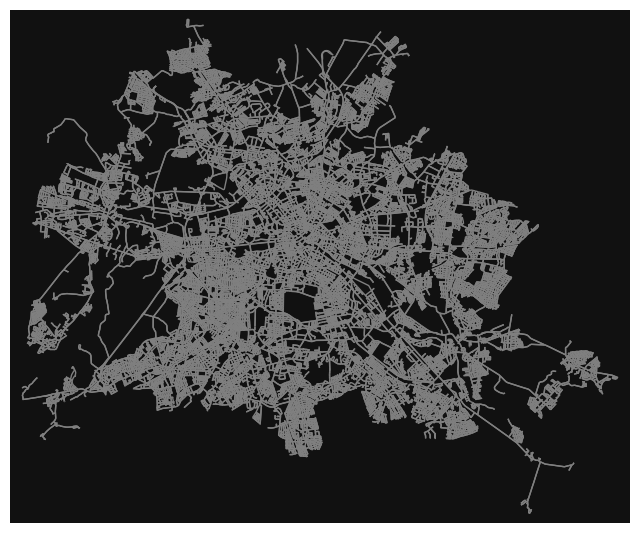

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
GRAPHML_PATH = os.path.join('data', 'berlin.graphml')
os.makedirs('data', exist_ok=True)

if os.path.exists(GRAPHML_PATH):
    print('Loading cached graph from', GRAPHML_PATH)
    G = ox.load_graphml(GRAPHML_PATH)
else:
    print('Downloading Berlin OSM graph (drive network) ...')
    G = ox.graph_from_place('Berlin, Germany', network_type='drive')
    ox.save_graphml(G, GRAPHML_PATH)

ox.plot_graph(G, edge_color='gray', node_size=0)

## Prepare graph edges (roads)

In [5]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to the same CRS as the noise points (EPSG:25833 — ETRS89 / UTM 33N)
roads = edges[edges.geometry.type == 'LineString'].to_crs(noise_points.crs)
print('Roads:', len(roads), 'CRS:', roads.crs)

Roads: 73649 CRS: EPSG:25833


## Check features completeness

In [6]:
print("Checking width..")
print(roads['width'].value_counts(dropna=False).head(20))
print("Checking maxspeed..")
print(roads['maxspeed'].value_counts(dropna=False).head(20))
print("Checking lanes..")
print(roads['lanes'].value_counts(dropna=False).head(20))
print("Checking oneway..")
print(roads['oneway'].value_counts(dropna=False))

Checking width..
width
NaN    55925
6       2347
5       1072
8        970
11       958
7        819
9        725
5.5      631
6.5      583
10       574
12       523
3        387
7.5      386
4        327
8.5      252
4.5      245
15       165
6.3      142
5.8      140
3.5      132
Name: count, dtype: int64
Checking maxspeed..
maxspeed
30          47898
50          18200
NaN          5243
[30, 50]      732
20            339
10            337
60            317
80            116
5              96
[30, 10]       51
[60, 50]       46
[20, 30]       44
8              18
[70, 50]       17
40             17
[80, 60]       16
15             16
[80, 50]       15
[60, 80]       14
[5, 30]        12
Name: count, dtype: int64
Checking lanes..
lanes
NaN          50248
2            13956
1             3726
3             1881
[3, 2]        1490
4              891
[1, 2]         373
[4, 2]         261
[4, 3]         209
5              123
[5, 4]         101
[4, 3, 2]       73
[3, 4]          56
[3, 1]

## Check if road is tunnel

In [7]:
# OSM 'tunnel' values can be strings or lists — mark as tunnel if any value is 'yes'
if 'tunnel' in roads.columns:
    roads['is_tunnel'] = roads['tunnel'].apply(
        lambda v: 1 if v == 'yes' or (isinstance(v, list) and 'yes' in v) else 0
    )
else:
    roads['is_tunnel'] = 0

print(roads['is_tunnel'].value_counts())

is_tunnel
0    73554
1       95
Name: count, dtype: int64


## Filter roads categories

In [8]:
# Filter to only primary and secondary roads
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)&
    (roads['is_tunnel'] == 0)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 73649, Filtered: 70890


## Plot road categories distribution

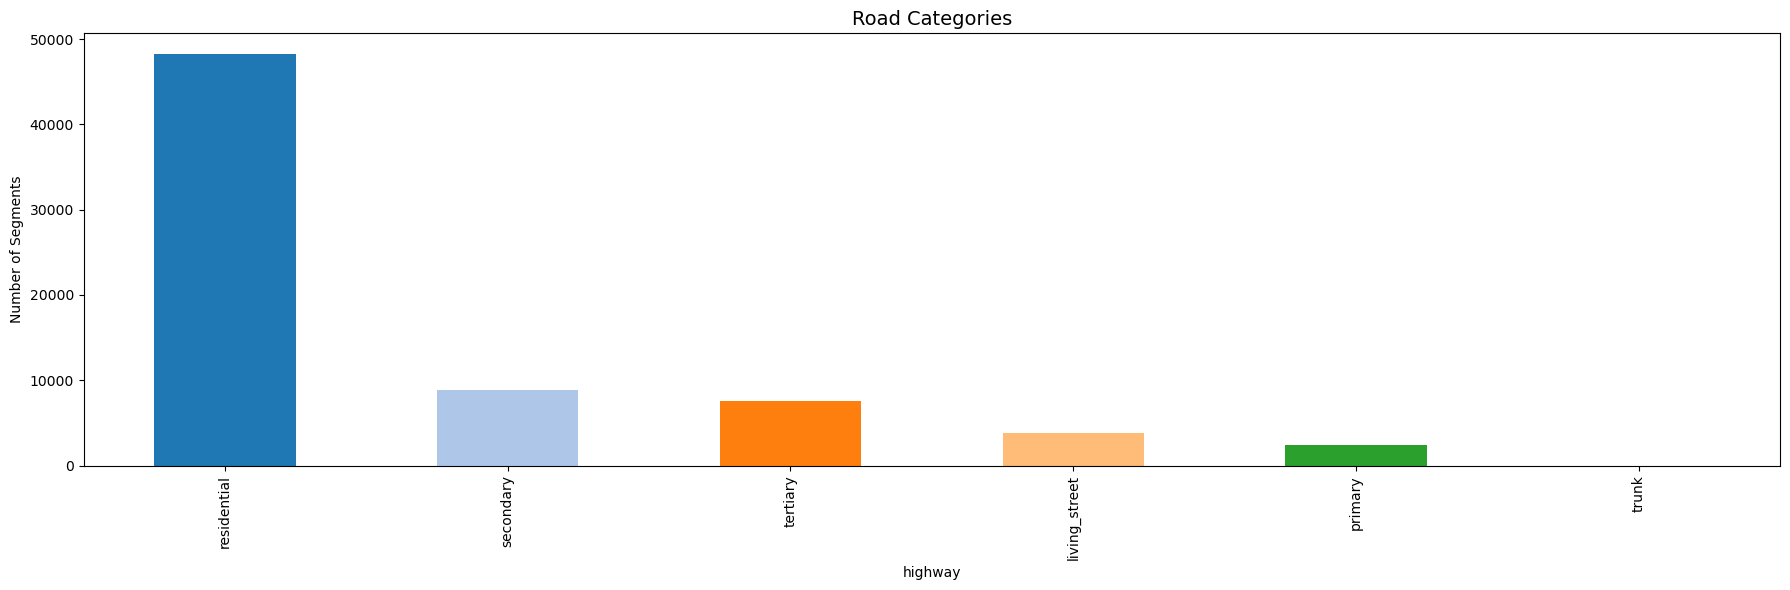

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

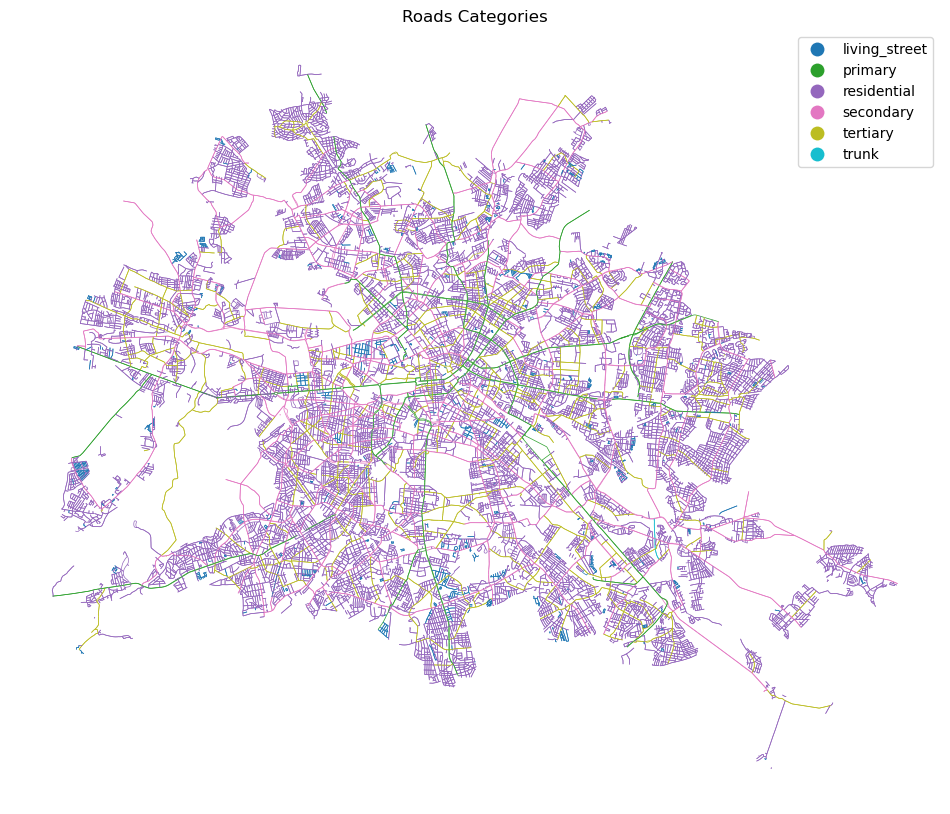

In [10]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Project noise points onto road segments

Each sampled facade point is assigned to its nearest road within **50 m**; the per-segment noise is the **mean** of its points. Roads with no point within 50 m inherit the value of the single nearest point (with the distance recorded).

In [11]:
# Step 1: assign each point to its nearest road within 50 m
points_joined = gpd.sjoin_nearest(
    noise_points,
    roads_filtered[['segment_id', 'geometry']],
    how='inner',
    max_distance=50,
    distance_col='dist_point_road'
)
print(f"Points matched to a road within 50 m: {len(points_joined)} / {len(noise_points)}")

# Step 2: aggregate per road segment — mean dB and point count
agg = points_joined.groupby('segment_id').agg(
    GES_DEN_mean=('GES_DEN', 'mean'),
    GES_N_mean=('GES_N', 'mean'),
    n_points=('GES_DEN', 'size'),
)

noise_roads = roads_filtered.merge(agg, on='segment_id', how='left')
noise_roads['distance'] = 0.0

# Step 3: fallback — roads without any point within 50 m get the nearest point value
unmatched_mask = noise_roads['GES_DEN_mean'].isna()
print(f"Roads without points within 50 m: {unmatched_mask.sum()} / {len(noise_roads)}")

if unmatched_mask.any():
    unmatched = noise_roads.loc[unmatched_mask, ['segment_id', 'geometry']]
    nearest = gpd.sjoin_nearest(
        unmatched,
        noise_points[['GES_DEN', 'GES_N', 'geometry']],
        how='left',
        distance_col='dist_fallback'
    )
    nearest = nearest.loc[~nearest.index.duplicated(keep='first')]
    noise_roads.loc[unmatched_mask, 'GES_DEN_mean'] = nearest['GES_DEN'].values
    noise_roads.loc[unmatched_mask, 'GES_N_mean'] = nearest['GES_N'].values
    noise_roads.loc[unmatched_mask, 'n_points'] = 0
    noise_roads.loc[unmatched_mask, 'distance'] = nearest['dist_fallback'].values

noise_roads['n_points'] = noise_roads['n_points'].astype(int)
print(f"Filtered roads: {len(roads_filtered)}, With noise: {noise_roads['GES_DEN_mean'].notna().sum()}")
print(noise_roads[['GES_DEN_mean', 'GES_N_mean', 'n_points', 'distance']].describe().round(1))

Points matched to a road within 50 m: 666697 / 500000
Roads without points within 50 m: 15901 / 70890


Filtered roads: 70890, With noise: 70890
       GES_DEN_mean  GES_N_mean  n_points  distance
count       70890.0     70890.0   70890.0   70890.0
mean           52.2        44.6       9.4      10.1
std             8.6         8.4      10.8      32.2
min            24.8        16.8       0.0       0.0
25%            45.6        38.1       1.0       0.0
50%            50.5        42.9       6.0       0.0
75%            58.0        50.1      14.0       0.0
max            89.1        81.9     138.0     906.0


## Classify noise into 5 classes: <40, 40-50, 50-60, 60-70, >70

In [12]:
# Classify numeric noise dB into 5 classes: 0=<40, 1=40-50, 2=50-60, 3=60-70, 4=>70

def classify_noise(val):
    if val < 40:
        return 0
    elif val < 50:
        return 1
    elif val < 60:
        return 2
    elif val < 70:
        return 3
    else:
        return 4

print(classify_noise(72.3))  # expected: 4

4


In [13]:
# Berlin only has Lden (day-evening-night) and Lnight — evening is set equal to day
noise_roads['noise_day'] = noise_roads['GES_DEN_mean'].apply(classify_noise)
noise_roads['noise_evening'] = noise_roads['noise_day']
noise_roads['noise_night'] = noise_roads['GES_N_mean'].apply(classify_noise)

noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,width,...,service,segment_id,is_tunnel,GES_DEN_mean,GES_N_mean,n_points,distance,noise_day,noise_evening,noise_night
0,"[33231778, 31740296, 4804202, 1119769231, 1119...",secondary,"[1, 3, 2]",50,Gotthardstraße,False,False,436.954554,"LINESTRING (387179.738 5825206.873, 387173.312...",NaN,...,NaN,172539_172562_0,0,53.849999,46.000000,4,0.00000,2,2,1
1,"[5117633, 1394523518, 1394523517, 1460128990, ...",secondary,2,50,Gotthardstraße,False,True,687.372277,"LINESTRING (387179.738 5825206.873, 387187.035...",13,...,NaN,172539_34694336_0,0,55.025000,47.531251,16,0.00000,2,2,1
2,"[1420016640, 1420016641, 1420016642, 118844605...",tertiary,2,50,Holländerstraße,False,False,240.982380,"LINESTRING (387179.738 5825206.873, 387184.593...",NaN,...,NaN,172539_34694265_0,0,59.366667,49.953333,15,0.00000,2,2,1
3,24973218,tertiary,NaN,50,Teichstraße,False,False,17.178731,"LINESTRING (387937.322 5825392.369, 387939.154...",15,...,NaN,172545_271370539_0,0,65.300003,56.900002,0,33.40436,3,3,2
4,40817055,secondary,2,50,Gotthardstraße,True,False,103.173761,"LINESTRING (387937.322 5825392.369, 387930.158...",9,...,NaN,172545_34694336_0,0,57.033333,48.916667,6,0.00000,2,2,1


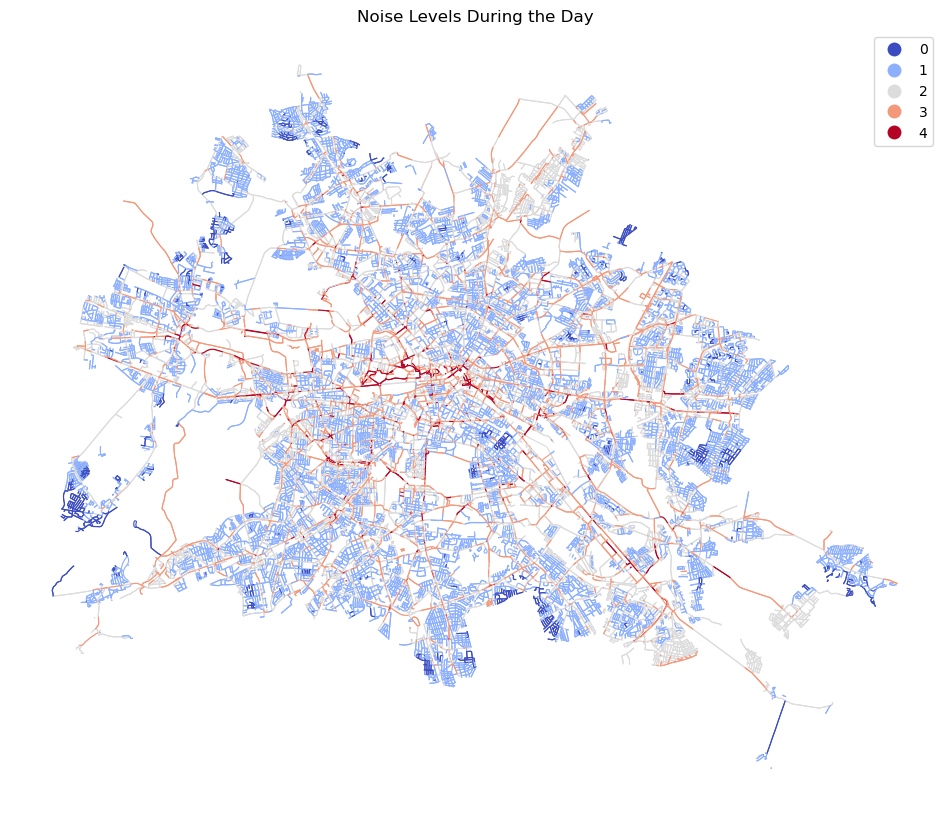

In [14]:
noise_roads['noise_day'] = noise_roads["noise_day"].astype("category")
ax = noise_roads.plot(cmap="coolwarm", column='noise_day',categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Noise Levels During the Day')
ax.set_axis_off()

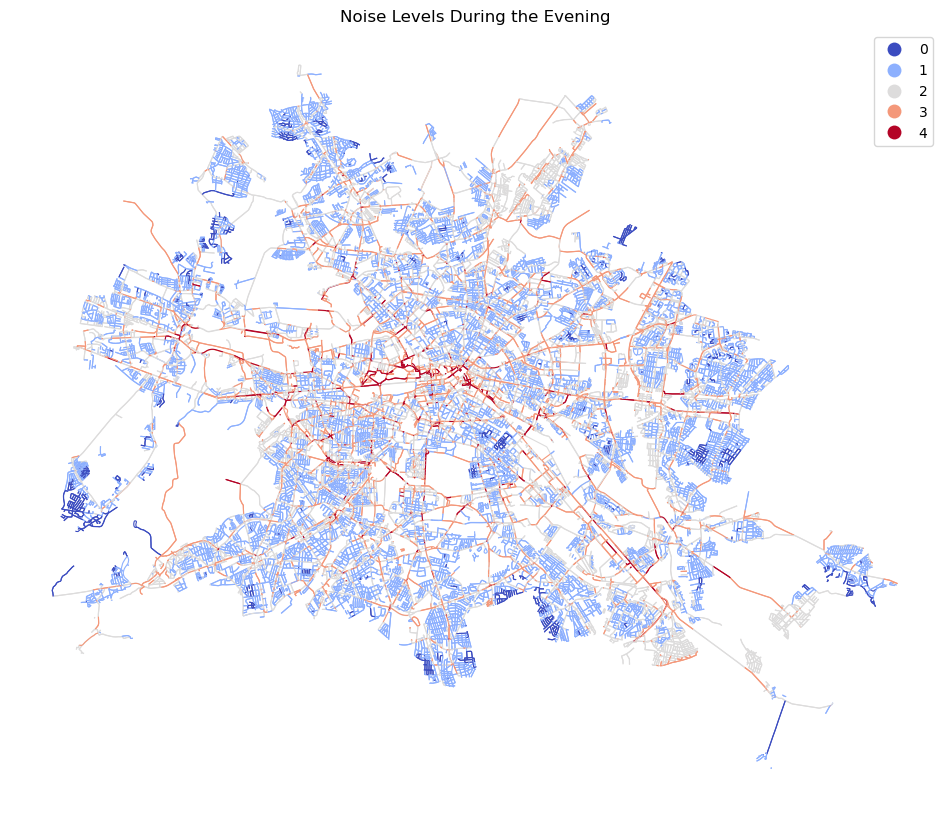

In [15]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Noise Levels During the Evening')
ax.set_axis_off()

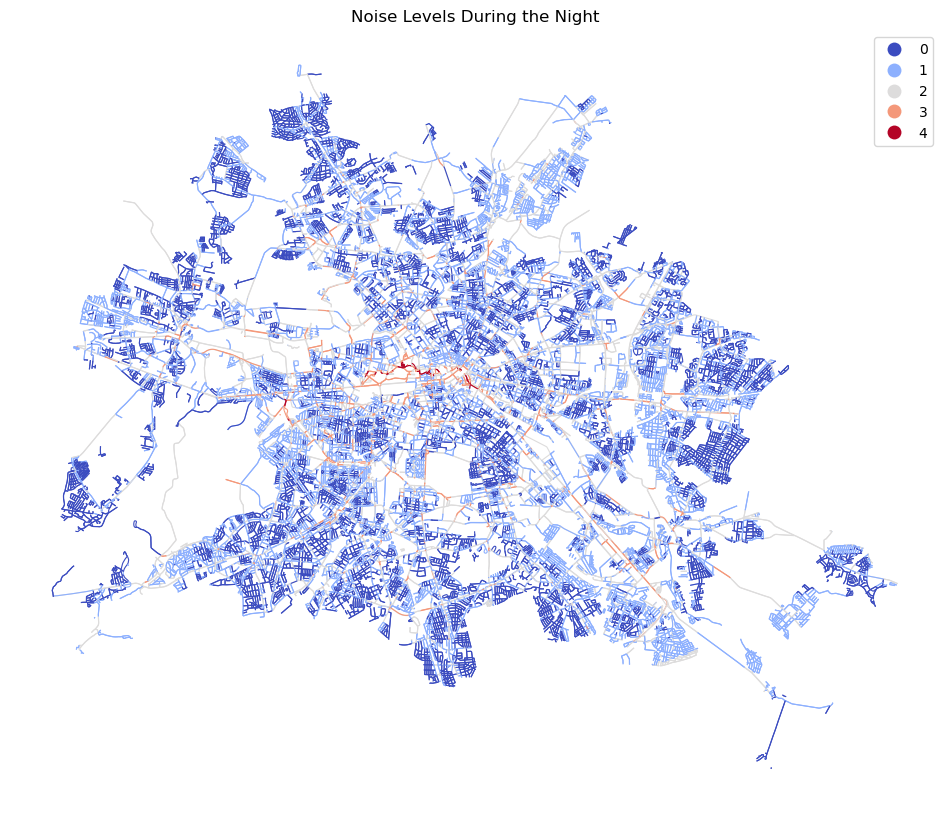

In [16]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Noise Levels During the Night')
ax.set_axis_off()

## Convert category to numerical feature

In [17]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      48258
secondary         8827
tertiary          7557
living_street     3834
primary           2408
trunk                6
Name: count, dtype: int64

In [18]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,width,...,is_tunnel,GES_DEN_mean,GES_N_mean,n_points,distance,noise_day,noise_evening,noise_night,road_category,category_code
0,"[33231778, 31740296, 4804202, 1119769231, 1119...",secondary,"[1, 3, 2]",50,Gotthardstraße,False,False,436.954554,"LINESTRING (387179.738 5825206.873, 387173.312...",NaN,...,0,53.849999,46.000000,4,0.00000,2,2,1,secondary,3
1,"[5117633, 1394523518, 1394523517, 1460128990, ...",secondary,2,50,Gotthardstraße,False,True,687.372277,"LINESTRING (387179.738 5825206.873, 387187.035...",13,...,0,55.025000,47.531251,16,0.00000,2,2,1,secondary,3
2,"[1420016640, 1420016641, 1420016642, 118844605...",tertiary,2,50,Holländerstraße,False,False,240.982380,"LINESTRING (387179.738 5825206.873, 387184.593...",NaN,...,0,59.366667,49.953333,15,0.00000,2,2,1,tertiary,4
3,24973218,tertiary,NaN,50,Teichstraße,False,False,17.178731,"LINESTRING (387937.322 5825392.369, 387939.154...",15,...,0,65.300003,56.900002,0,33.40436,3,3,2,tertiary,4
4,40817055,secondary,2,50,Gotthardstraße,True,False,103.173761,"LINESTRING (387937.322 5825392.369, 387930.158...",9,...,0,57.033333,48.916667,6,0.00000,2,2,1,secondary,3


## Calculate distance to the closest road of each category

In [19]:
# Ensure unique index and keep a stable row id for repeated nearest joins
noise_roads = noise_roads.reset_index(drop=True).copy()
noise_roads['road_idx'] = noise_roads.index

# Drop join helper columns if they exist to avoid conflicts in repeated runs
join_helper_cols = ['index_right'] + [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads = noise_roads.drop(columns=[col for col in join_helper_cols if col in noise_roads.columns], errors='ignore')

road_categories = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']

for category in road_categories:
    category_roads = noise_roads[noise_roads['highway'] == category][['geometry']].copy()
    distance_col = f'dist_to_{category}'

    if category_roads.empty:
        noise_roads[distance_col] = pd.NA
        continue

    nearest_category = noise_roads[['road_idx', 'geometry']].sjoin_nearest(
        category_roads,
        how='left',
        distance_col=distance_col
    )
    min_distances = nearest_category.groupby('road_idx')[distance_col].min()
    noise_roads[distance_col] = noise_roads['road_idx'].map(min_distances)

noise_roads = noise_roads.drop(columns=['road_idx']).drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,width,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,"[33231778, 31740296, 4804202, 1119769231, 1119...",secondary,"[1, 3, 2]",50,Gotthardstraße,False,False,436.954554,"LINESTRING (387179.738 5825206.873, 387173.312...",NaN,...,2,1,secondary,3,19406.495889,0.000000,0.0,0.0,130.367348,845.336539
1,"[5117633, 1394523518, 1394523517, 1460128990, ...",secondary,2,50,Gotthardstraße,False,True,687.372277,"LINESTRING (387179.738 5825206.873, 387187.035...",13,...,2,1,secondary,3,19015.019606,435.703514,0.0,0.0,0.000000,867.701362
2,"[1420016640, 1420016641, 1420016642, 118844605...",tertiary,2,50,Holländerstraße,False,False,240.982380,"LINESTRING (387179.738 5825206.873, 387184.593...",NaN,...,2,1,tertiary,4,19175.649431,431.894550,0.0,0.0,0.000000,867.701362
3,24973218,tertiary,NaN,50,Teichstraße,False,False,17.178731,"LINESTRING (387937.322 5825392.369, 387939.154...",15,...,3,2,tertiary,4,18944.230854,800.614365,0.0,0.0,101.228333,996.552367
4,40817055,secondary,2,50,Gotthardstraße,True,False,103.173761,"LINESTRING (387937.322 5825392.369, 387930.158...",9,...,2,1,secondary,3,18957.026756,800.614365,0.0,0.0,0.000000,996.552367


In [20]:
# Summarize distance-to-category features
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads[distance_cols].describe()

,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
count,70890.000000,70890.000000,70890.000000,70890.000000,70890.000000,70890.000000
mean,14251.933267,1489.564200,369.757456,337.889882,11.506118,621.627843
std,7243.453989,1583.174927,506.030211,382.831363,48.884373,591.335209
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8644.225385,389.991131,11.563476,38.866639,0.000000,224.385309
50%,13942.624070,1047.749125,222.905283,235.816321,0.000000,487.311863
75%,18990.907891,2085.302344,495.194730,480.225428,0.000000,827.743186
max,31024.588410,11767.738425,4556.692447,3409.130152,1998.417666,5163.223954


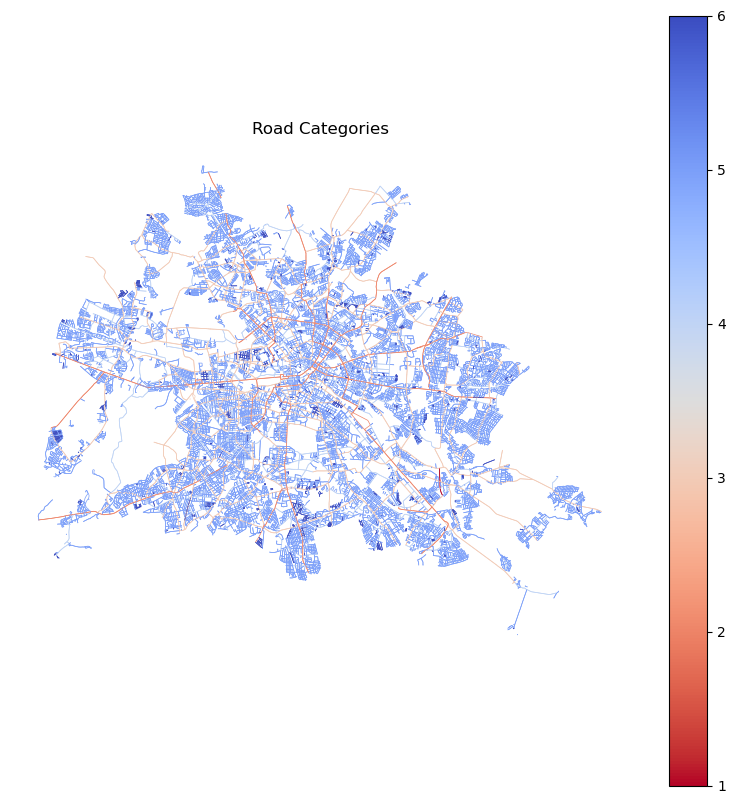

In [21]:
# Plot Road Categories
ax = noise_roads.plot(column='category_code', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [22]:
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,width,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,"[33231778, 31740296, 4804202, 1119769231, 1119...",secondary,"[1, 3, 2]",50,Gotthardstraße,False,False,436.954554,"LINESTRING (387179.738 5825206.873, 387173.312...",NaN,...,2,1,secondary,3,19406.495889,0.000000,0.0,0.0,130.367348,845.336539
1,"[5117633, 1394523518, 1394523517, 1460128990, ...",secondary,2,50,Gotthardstraße,False,True,687.372277,"LINESTRING (387179.738 5825206.873, 387187.035...",13,...,2,1,secondary,3,19015.019606,435.703514,0.0,0.0,0.000000,867.701362
2,"[1420016640, 1420016641, 1420016642, 118844605...",tertiary,2,50,Holländerstraße,False,False,240.982380,"LINESTRING (387179.738 5825206.873, 387184.593...",NaN,...,2,1,tertiary,4,19175.649431,431.894550,0.0,0.0,0.000000,867.701362
3,24973218,tertiary,NaN,50,Teichstraße,False,False,17.178731,"LINESTRING (387937.322 5825392.369, 387939.154...",15,...,3,2,tertiary,4,18944.230854,800.614365,0.0,0.0,101.228333,996.552367
4,40817055,secondary,2,50,Gotthardstraße,True,False,103.173761,"LINESTRING (387937.322 5825392.369, 387930.158...",9,...,2,1,secondary,3,18957.026756,800.614365,0.0,0.0,0.000000,996.552367


## Export Berlin noise streets layer

Save the OSM streets with their projected noise values as a GeoPackage in `deployment/Berlin/layers/`.

In [23]:
export_cols = ['segment_id', 'highway', 'name', 'length',
               'GES_DEN_mean', 'GES_N_mean',
               'noise_day', 'noise_evening', 'noise_night',
               'n_points', 'distance', 'geometry']

noise_streets_export = noise_roads[export_cols].copy()
# OSM columns can contain lists, and noise classes are pandas categories — cast for GPKG
noise_streets_export['name'] = noise_streets_export['name'].astype(str)
noise_streets_export['highway'] = noise_streets_export['highway'].astype(str)
noise_streets_export['noise_day'] = noise_streets_export['noise_day'].astype(int)
noise_streets_export['noise_evening'] = noise_streets_export['noise_evening'].astype(int)
noise_streets_export['noise_night'] = noise_streets_export['noise_night'].astype(int)

_out_path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers', 'BER_noise_streets.gpkg')
noise_streets_export.to_file(_out_path, layer='noise_streets', driver='GPKG')
print('Exported', len(noise_streets_export), 'noise streets to:', _out_path)

Exported 70890 noise streets to: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Berlin\layers\BER_noise_streets.gpkg


## Create data frame

In [24]:
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]

dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'],
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_category": noise_roads['category_code'],
    **{col: noise_roads[col] for col in distance_cols},
}).fillna(0)

dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,172539_172562_0,2,2,1,3,19406.495889,0.000000,0.0,0.0,130.367348,845.336539
1,172539_34694336_0,2,2,1,3,19015.019606,435.703514,0.0,0.0,0.000000,867.701362
2,172539_34694265_0,2,2,1,4,19175.649431,431.894550,0.0,0.0,0.000000,867.701362
3,172545_271370539_0,3,3,2,4,18944.230854,800.614365,0.0,0.0,101.228333,996.552367
4,172545_34694336_0,2,2,1,3,18957.026756,800.614365,0.0,0.0,0.000000,996.552367


## Export dataset to CSV

In [25]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_noise_class.csv"), index=False)
print("Exported osm_roads_noise_class.csv")

Exported osm_roads_noise_class.csv
